In [3]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load the dataset
data = fetch_california_housing(as_frame=True)
df = data.frame
print(df.head())

# Separate predictors (X) from the target (y)
X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

# Train-test split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

# Train a Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate with R²
train_r2 = r2_score(y_train, model.predict(X_train))
test_r2 = r2_score(y_test, model.predict(X_test))

print(f"Training R²: {train_r2:.4f}")
print(f"Test R²:     {test_r2:.4f}")



   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
Training samples: 16512
Testing samples:  4128
Training R²: 0.6126
Test R²:     0.5758


             MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc         1.00     -0.12      0.33      -0.06        0.00      0.02   
HouseAge      -0.12      1.00     -0.15      -0.08       -0.30      0.01   
AveRooms       0.33     -0.15      1.00       0.85       -0.07     -0.00   
AveBedrms     -0.06     -0.08      0.85       1.00       -0.07     -0.01   
Population     0.00     -0.30     -0.07      -0.07        1.00      0.07   
AveOccup       0.02      0.01     -0.00      -0.01        0.07      1.00   
Latitude      -0.08      0.01      0.11       0.07       -0.11      0.00   
Longitude     -0.02     -0.11     -0.03       0.01        0.10      0.00   
MedHouseVal    0.69      0.11      0.15      -0.05       -0.02     -0.02   

             Latitude  Longitude  MedHouseVal  
MedInc          -0.08      -0.02         0.69  
HouseAge         0.01      -0.11         0.11  
AveRooms         0.11      -0.03         0.15  
AveBedrms        0.07       0.01        -0.05  

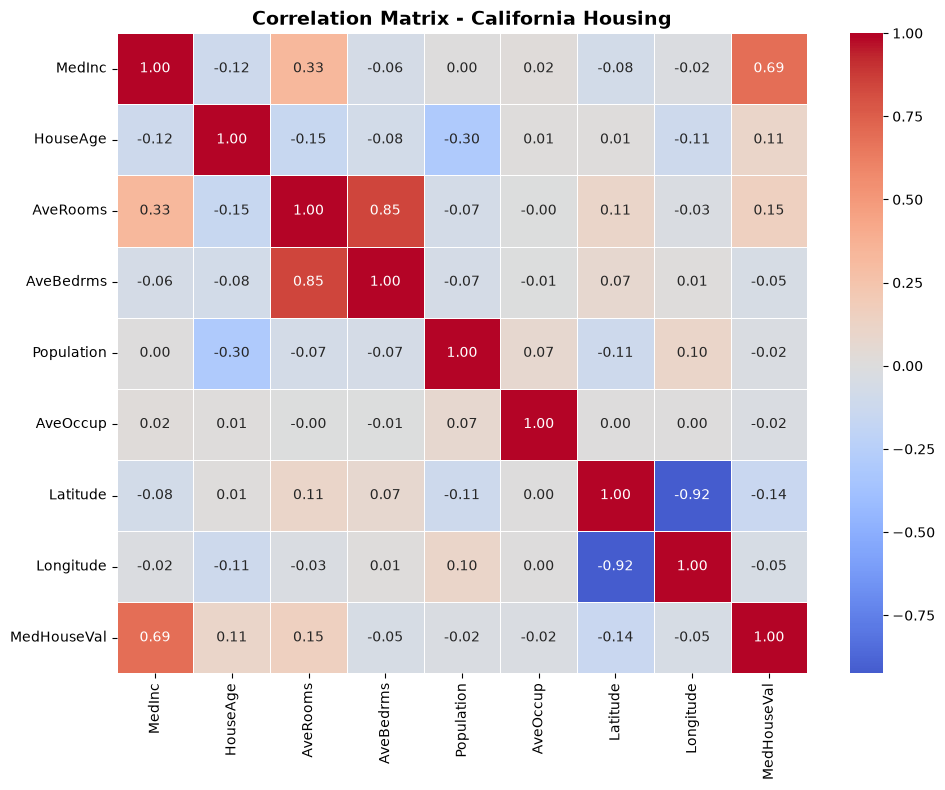


Top 3 features correlated with MedHouseVal:
  MedInc: 0.6881
  AveRooms: 0.1519
  Latitude: -0.1442

Correlation vs regression coefficient:
            Correlation  Coefficient
MedInc           0.6881       0.4487
AveRooms         0.1519      -0.1233
Latitude        -0.1442      -0.4198
HouseAge         0.1056       0.0097
AveBedrms       -0.0467       0.7831
Longitude       -0.0460      -0.4337
Population      -0.0246      -0.0000
AveOccup        -0.0237      -0.0035


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Correlation matrix for all numeric variables
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix.round(2))

# 2. Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5)
plt.title("Correlation Matrix - California Housing", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 3. Top three features most strongly correlated with MedHouseVal
# (ranked by absolute value, so strong negative correlations count too)
target_corr = corr_matrix["MedHouseVal"].drop("MedHouseVal")
top3 = target_corr.abs().sort_values(ascending=False).head(3).index
print("\nTop 3 features correlated with MedHouseVal:")
for feature in top3:
    print(f"  {feature}: {target_corr[feature]:.4f}")

# 4. Compare with the regression coefficients from Task 1
coefficients = pd.Series(model.coef_, index=X.columns)
comparison = pd.DataFrame({
    "Correlation": target_corr,
    "Coefficient": coefficients,
}).loc[target_corr.abs().sort_values(ascending=False).index]
print("\nCorrelation vs regression coefficient:")
print(comparison.round(4))